In [1]:
import pandas as pd


# Load the first CSV file
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Load the second CSV file
subject_metadata_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/subject_metadata.csv"
subject_metadata = pd.read_csv(subject_metadata_path)


# Number of unique UserIds in train_data
num_user_ids = train_data['UserId'].nunique()

# Number of questions answered
num_questions_answered = len(train_data)

# Number of unique concepts answered
num_concepts_answered = train_data['Concept'].nunique()

print(f"Number of UserIds: {num_user_ids}")
print(f"Number of questions answered: {num_questions_answered}")
print(f"Number of concepts answered: {num_concepts_answered}")

print("Columns in train_task_3_4_with_concept:", train_data.columns)
print("Columns in subject_metadata:", subject_metadata.columns)



Number of UserIds: 4918
Number of questions answered: 1382727
Number of concepts answered: 57
Columns in train_task_3_4_with_concept: Index(['QuestionId', 'UserId', 'AnswerId', 'IsCorrect', 'CorrectAnswer',
       'AnswerValue', 'Concept'],
      dtype='object')
Columns in subject_metadata: Index(['SubjectId', 'Name', 'ParentId', 'Level'], dtype='object')


In [2]:
# ایجاد یک مجموعه از مفاهیم موجود در train_data
train_data_concepts = set(train_data['Concept'].unique())

# ایجاد یک مجموعه از مفاهیم موجود در subject_metadata
subject_metadata_concepts = set(subject_metadata['SubjectId'])

# چک کردن مفاهیم وجود دار در train_data اما در subject_metadata ندارند
missing_concepts = train_data_concepts - subject_metadata_concepts

# چاپ مفاهیمی که در train_data وجود دارند اما در subject_metadata ندارند
print("Missing Concepts in subject_metadata:", missing_concepts)

# چاپ یک نمونه از train_data برای بررسی اطلاعات
print(train_data.head())


Missing Concepts in subject_metadata: {2, 162, 194, 134, 135, 136, 169, 201, 299, 43, 145, 147, 20, 150, 155, 124, 125, 127}
   QuestionId  UserId  AnswerId  IsCorrect  CorrectAnswer  AnswerValue  \
0         898    2111    280203          1              2            2   
1         767    3062     55638          1              3            3   
2         165    1156    386475          1              2            2   
3         490    1653    997498          1              4            4   
4         298    3912    578636          1              3            3   

   Concept  
0       38  
1      147  
2      163  
3      266  
4      125  


In [3]:
# افزودن اطلاعات مفاهیم به subject_metadata

for concept_id in missing_concepts:

    # اطلاعات مفاهیم موجود در train_data را بازیابی کنید
    concept_info = train_data[train_data['Concept'] == concept_id].iloc[0]

    # اضافه کردن اطلاعات به subject_metadata
    subject_metadata.loc[len(subject_metadata.index)] = {'SubjectId': concept_info['Concept'], 'Name': concept_info['Concept']}


# چاپ subject_metadata بعد از اضافه کردن اطلاعات
print(subject_metadata)

     SubjectId                    Name  ParentId  Level
0            3                   Maths       NaN    0.0
1           32                  Number       3.0    1.0
2           33                  BIDMAS     144.0    3.0
3           34  Upper and Lower Bounds     141.0    3.0
4           35          Calculator Use      32.0    2.0
..         ...                     ...       ...    ...
401        150                     150       NaN    NaN
402        155                     155       NaN    NaN
403        124                     124       NaN    NaN
404        125                     125       NaN    NaN
405        127                     127       NaN    NaN

[406 rows x 4 columns]


In [4]:
import random
import pandas as pd
import os

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
answered_concepts = train_data['Concept'].unique()

# Filter the data to include only rows with answered concepts
filtered_data = train_data[train_data['Concept'].isin(answered_concepts)]

# Group by UserId
grouped_data = filtered_data.groupby('UserId')

# Create Episodes
episodes = []

for _, group in grouped_data:
    # Use all questions for each user with answered concepts
    episode = group.copy()
    episodes.append(episode)

# Save Episodes (between 6000 and 8000)
num_available_episodes = len(episodes)
num_episodes = min(random.randint(6000, 8000), num_available_episodes)

selected_episodes = random.sample(episodes, num_episodes)
selected_episodes_df = pd.concat(selected_episodes)

# Change 'your_absolute_path' to the actual path where you have write permission
os.chdir('C:/Users/malih/OneDrive/Desktop/code1/Final')
selected_episodes_df.to_csv('Episode.csv', index=False)


## **Bellman**

Q(s,a)=(1−α)⋅Q(s,a)+α⋅(r+γ⋅maxaQ(s′,a))



Episode: 1, Current State: 163 - Transformations of functions in the form y =, Current Action: Unknown Action, Next State: 41 - Basic Money, Next Action: Unknown Action, Reward: 0, Student Answer: 4
Episode: 1, Current State: 41 - Basic Money, Current Action: Unknown Action, Next State: 268 - Graphical Solution of Quadratic Equations, Next Action: Unknown Action, Reward: 1, Student Answer: 3
Episode: 1, Current State: 268 - Graphical Solution of Quadratic Equations, Current Action: Unknown Action, Next State: 126 - Differentiation, Next Action: Unknown Action, Reward: 1, Student Answer: 1
Episode: 1, Current State: 126 - Differentiation, Current Action: Unknown Action, Next State: 173 - Other Sequences, Next Action: Unknown Action, Reward: 1, Student Answer: 1
Episode: 1, Current State: 173 - Other Sequences, Current Action: Unknown Action, Next State: 60 - Rearranging Formula and Equations, Next Action: Unknown Action, Reward: 1, Student Answer: 4
Episode: 1, Current State: 60 - Rearr

<Figure size 1000x500 with 0 Axes>

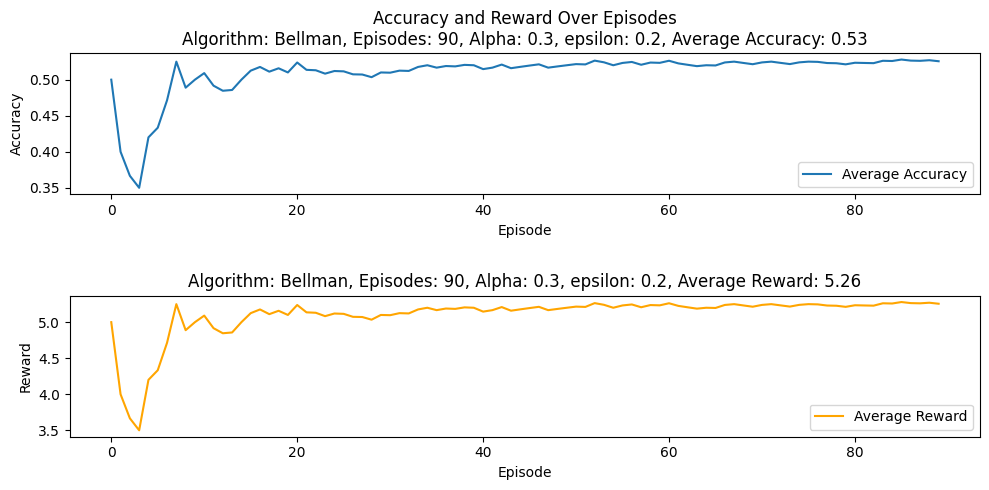

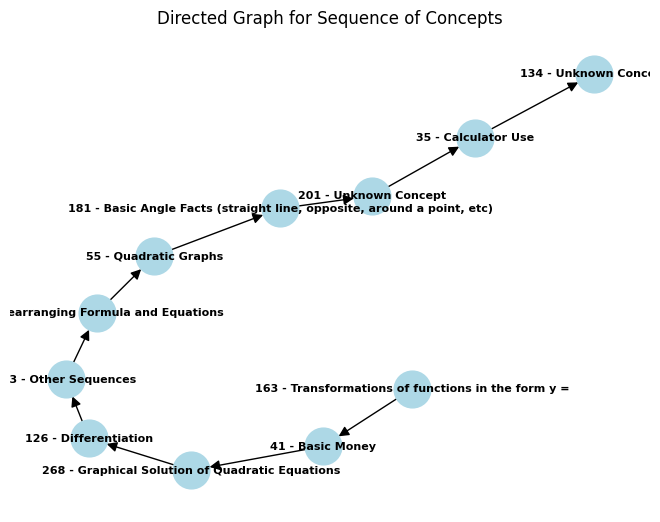

In [11]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Define a dictionary to map action numbers to action names
action_names = {
    0: 'Action_0',
    1: 'Action_1',
    # Add more action names as needed
}

# Load subject metadata from the CSV file
subject_metadata = pd.read_csv('subject_metadata.csv')

# Extract the relevant columns
concept_names = dict(zip(subject_metadata['SubjectId'], subject_metadata['Name']))

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
unique_concepts = train_data['Concept'].unique()

# Set the parameters
epsilon = 0.2  # Exploration-exploitation trade-off
alpha = 0.3  # Learning rate
gamma = 0.9  # Discount factor
concept_count = len(unique_concepts)  # Number of concepts

# Initialize Q-values
q_values = {(state, action): 0 for state in unique_concepts for action in unique_concepts}

# Select 10 random concepts for the graph
selected_concepts = random.sample(list(unique_concepts), 11)

# Create a graph representing the chain of concepts
graph = {selected_concepts[i]: selected_concepts[i + 1] for i in range(10)}

# Variables to track accuracy and reward for each episode
episode_accuracies = []
episode_rewards = []

# Initialize lists to store average accuracy and total reward for each episode
average_accuracy_episodes = []
average_reward_episodes = []

# Initialize total accuracy and total reward for each episode
total_accuracy_episode = 0
total_reward_episode = 0

# Q-learning algorithm
num_episodes = 90

for episode in range(num_episodes):
    state = selected_concepts[0]  # Initial state
    episode_accuracy = 0
    episode_reward = 0

    while state != selected_concepts[-1]:  # Continue until reaching the last state
   
    
        # Exploration-exploitation trade-off
        if random.uniform(0, 1) < epsilon:
            # Exploration: Select a random action
            action = random.choice(list(q_values.keys()))
        else:
            # Exploitation: Select the action with the highest Q-value
            possible_actions = [act for act in unique_concepts if (state, act) in q_values]
            if not possible_actions:
                print(f"Episode: {episode + 1}, Current State: {state}, Reward: 0, No available actions for this state.")
                break  # Exit the episode if no actions are available for the current state
            action = max(possible_actions, key=lambda act: q_values[(state, act)])

        # Simulate asking the question and receiving the student's answer
        # Use all questions related to the selected concept
        concept_questions = train_data[train_data['Concept'] == state]
        if concept_questions.empty:
            print(f"Episode: {episode + 1}, Current State: {state}, Current Action: {action}, Reward: 0, No available questions for this concept.")
            break  # Exit the episode if no questions are available for the current concept
        question_data = concept_questions.sample(1).iloc[0]
        student_answer = question_data['AnswerValue']

        # Calculate reward based on correctness of the student's answer
        reward = 1 if question_data['IsCorrect'] == 1 else 0

        # Update Q-value using the Bellman formula
        next_state = graph[state]
        if (next_state, action) not in q_values:
            q_values[(next_state, action)] = 0  # Initialize Q-value if not present
        best_next_action = max(unique_concepts, key=lambda act: q_values[(next_state, act)])
        if (state, action) not in q_values:
            q_values[(state, action)] = 0  # Initialize Q-value if not present
        q_values[(state, action)] = (1 - alpha) * q_values[(state, action)] + alpha * (reward + gamma * max(q_values[(next_state, act)] for act in unique_concepts))

                           #Q(s,a)=(1−α)⋅Q(s,a)+α⋅(r+γ⋅maxaQ(s′,a))

        # Inside the loop where you print information for each step, add the following lines to print the action and concept names
        current_action_name = action_names.get(action, 'Unknown Action')
        next_action_name = action_names.get(best_next_action, 'Unknown Action')  # Fixed line
        current_concept_number = state
        next_concept_number = next_state
        current_concept_name = concept_names.get(state, 'Unknown Concept')
        next_concept_name = concept_names.get(next_state, 'Unknown Concept')

        print(f"Episode: {episode + 1}, Current State: {current_concept_number} - {current_concept_name}, Current Action: {current_action_name}, Next State: {next_concept_number} - {next_concept_name}, Next Action: {next_action_name}, Reward: {reward}, Student Answer: {student_answer}")
        # Move to the next state
        state = next_state

        # Calculate accuracy for the episode
        episode_accuracy += 1 if reward == 1 else 0
        episode_reward += reward

     
    # Update total accuracy and total reward for each episode
    total_accuracy_episode += episode_accuracy / (len(selected_concepts)-1)
    total_reward_episode += episode_reward
    average_accuracy_episode = total_accuracy_episode / (episode + 1)
    average_reward_episode = total_reward_episode / (episode + 1)

    # Append average accuracy and total reward to lists for plotting
    average_accuracy_episodes.append(average_accuracy_episode)
    average_reward_episodes.append(average_reward_episode)

    # Print accuracy and reward at the end of each episode
    print(f"Episode: {episode + 1}, Accuracy: {episode_accuracy}/{len(selected_concepts)-1}={episode_accuracy / (len(selected_concepts)-1):.1f}, Reward: {episode_reward}")

# Print average accuracy and average total reward at the end
print(f"\nAverage Accuracy Over Episodes: {average_accuracy_episode:.2f}")
print(f"Average Total Reward Over Episodes: {average_reward_episode:.2f}")


# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Plot accuracy over episodes
plt.subplot(2, 1, 1)
plt.plot(average_accuracy_episodes, label='Average Accuracy')
plt.title(f'Accuracy and Reward Over Episodes\nAlgorithm: Bellman, Episodes: {num_episodes}, Alpha: {alpha}, epsilon: {epsilon}, Average Accuracy: {average_accuracy_episode:.2f}')

plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()

# Plot reward over episodes with orange color
plt.subplot(2, 1, 2)
plt.plot(average_reward_episodes, color='orange', label='Average Reward')
plt.title(f'\nAlgorithm: Bellman, Episodes: {num_episodes}, Alpha: {alpha}, epsilon: {epsilon}, Average Reward: {average_reward_episode:.2f}')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.tight_layout()
plt.show()

# Create the directed graph for the sequence of selected concepts
edges = [(selected_concepts[i], selected_concepts[i + 1]) for i in range(10)]
G = nx.DiGraph(edges)

# Plot the directed graph for the sequence of concepts
pos = nx.spring_layout(G)
labels = {concept: f"{concept} - {concept_names.get(concept, 'Unknown Concept')}" for concept in selected_concepts}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', arrowsize=15)
plt.title('Directed Graph for Sequence of Concepts')
plt.show()

# Save the trained Q-values to a CSV file
q_values_df = pd.DataFrame(list(q_values.items()), columns=['State_Action', 'Q-Value'])
q_values_df.to_csv('Bellman_Trained_qlearning.csv', index=False)

## *Bellman*
## *for 10 RUNs*

Episode: 1, Run: 1, Current State: 172 - Quadratic Sequences, Current Action: Unknown Action, Next State: 219 - Factors and Highest Common Factor, Next Action: Unknown Action, Reward: 0, Student Answer: 4
Episode: 1, Run: 1, Current State: 219 - Factors and Highest Common Factor, Current Action: Unknown Action, Next State: 43 - Unknown Concept, Next Action: Unknown Action, Reward: 1, Student Answer: 2
Episode: 1, Run: 1, Current State: 43 - Unknown Concept, Current Action: Unknown Action, Next State: 41 - Basic Money, Next Action: Unknown Action, Reward: 0, Student Answer: 3
Episode: 1, Run: 1, Current State: 41 - Basic Money, Current Action: Unknown Action, Next State: 134 - Unknown Concept, Next Action: Unknown Action, Reward: 1, Student Answer: 4
Episode: 1, Run: 1, Current State: 134 - Unknown Concept, Current Action: Unknown Action, Next State: 164 - Transformations of functions in the form f(x), Next Action: Unknown Action, Reward: 1, Student Answer: 1
Episode: 1, Run: 1, Current

<Figure size 1000x500 with 0 Axes>

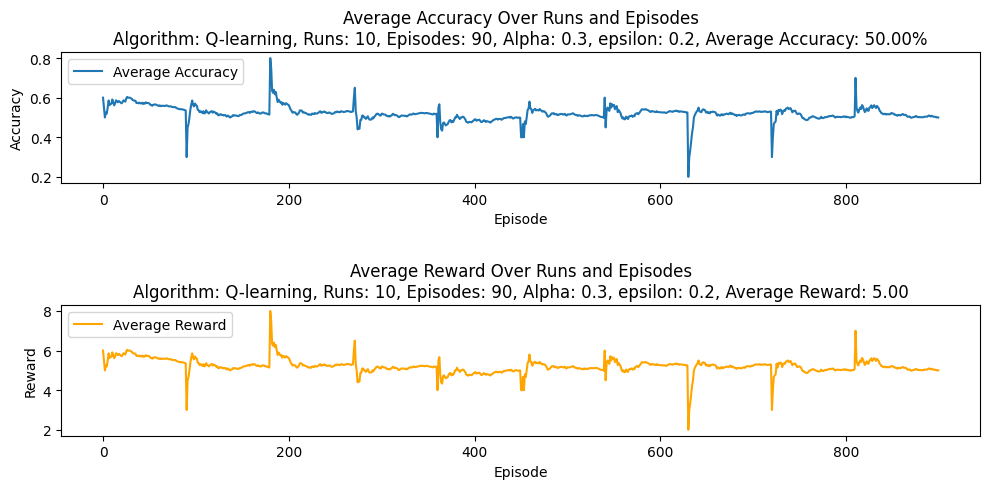

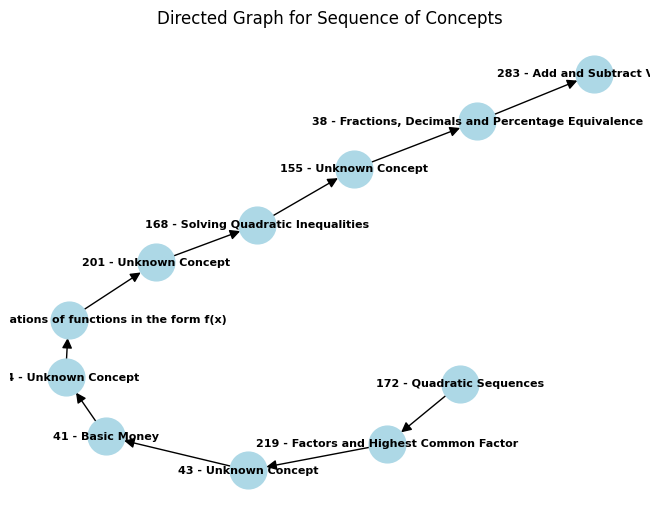

In [6]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Define a dictionary to map action numbers to action names
action_names = {
    0: 'Action_0',
    1: 'Action_1',
    # Add more action names as needed
}

# Load subject metadata from the CSV file
subject_metadata = pd.read_csv('subject_metadata.csv')

# Extract the relevant columns
concept_names = dict(zip(subject_metadata['SubjectId'], subject_metadata['Name']))

# Load the train data
train_data_path = "C:/Users/malih/OneDrive/Desktop/code1/q-learning/train_task_3_4_with_concept.csv"
train_data = pd.read_csv(train_data_path)

# Get unique concepts from the train data
unique_concepts = train_data['Concept'].unique()

# Set the parameters
epsilon = 0.2  # Exploration-exploitation trade-off
alpha = 0.3  # Learning rate
gamma = 0.9  # Discount factor
concept_count = len(unique_concepts)  # Number of concepts

# Select 10 random concepts for the graph
selected_concepts = random.sample(list(unique_concepts), 11)

# Create a graph representing the chain of concepts
graph = {selected_concepts[i]: selected_concepts[i + 1] for i in range(10)}

# Variables to track accuracy and reward for each episode
episode_accuracies = []
episode_rewards = []

# Initialize lists to store average accuracy and total reward for each episode
average_accuracy_episodes = []
average_reward_episodes = []

# Run the Q-learning algorithm 10 times
num_runs = 10
for run in range(num_runs):
    # Initialize Q-values for each run
    q_values = {(state, action): 0 for state in unique_concepts for action in unique_concepts}

    # Initialize total accuracy and total reward for each episode
    total_accuracy_episode = 0
    total_reward_episode = 0

    # Q-learning algorithm
    num_episodes = 90

    for episode in range(num_episodes):
        state = selected_concepts[0]  # Initial state
        episode_accuracy = 0
        episode_reward = 0

        while state != selected_concepts[-1]:  # Continue until reaching the last state
            # Exploration-exploitation trade-off
            if random.uniform(0, 1) < epsilon:
                # Exploration: Select a random action
                action = random.choice(list(q_values.keys()))
            else:
                # Exploitation: Select the action with the highest Q-value
                possible_actions = [act for act in unique_concepts if (state, act) in q_values]
                if not possible_actions:
                    print(f"Episode: {episode + 1}, Current State: {state}, Reward: 0, No available actions for this state.")
                    break  # Exit the episode if no actions are available for the current state
                action = max(possible_actions, key=lambda act: q_values[(state, act)])

            # Simulate asking the question and receiving the student's answer
            # Use all questions related to the selected concept
            concept_questions = train_data[train_data['Concept'] == state]
            if concept_questions.empty:
                print(f"Episode: {episode + 1}, Current State: {state}, Current Action: {action}, Reward: 0, No available questions for this concept.")
                break  # Exit the episode if no questions are available for the current concept
            question_data = concept_questions.sample(1).iloc[0]
            student_answer = question_data['AnswerValue']

            # Calculate reward based on correctness of the student's answer
            reward = 1 if question_data['IsCorrect'] == 1 else 0

            # Update Q-value using the Q-learning formula
            next_state = graph[state]
            if (next_state, action) not in q_values:
                q_values[(next_state, action)] = 0  # Initialize Q-value if not present
            best_next_action = max(unique_concepts, key=lambda act: q_values[(next_state, act)])
            if (state, action) not in q_values:
                q_values[(state, action)] = 0  # Initialize Q-value if not present
            q_values[(state, action)] = (1 - alpha) * q_values[(state, action)] + alpha * (reward + gamma * max(q_values[(next_state, act)] for act in unique_concepts))

                                 #  Q(s,a)=(1−α)⋅Q(s,a)+α⋅(r+γ⋅maxaQ(s′,a))



            # Inside the loop where you print information for each step, add the following lines to print the action and concept names
            current_action_name = action_names.get(action, 'Unknown Action')
            next_action_name = action_names.get(best_next_action, 'Unknown Action')  # Fixed line
            current_concept_number = state
            next_concept_number = next_state
            current_concept_name = concept_names.get(state, 'Unknown Concept')
            next_concept_name = concept_names.get(next_state, 'Unknown Concept')

            print(f"Episode: {episode + 1}, Run: {run + 1}, Current State: {current_concept_number} - {current_concept_name}, Current Action: {current_action_name}, Next State: {next_concept_number} - {next_concept_name}, Next Action: {next_action_name}, Reward: {reward}, Student Answer: {student_answer}")
            # Move to the next state
            state = next_state

            # Calculate accuracy for the episode
            episode_accuracy += 1 if reward == 1 else 0
            episode_reward += reward

        # Update total accuracy and total reward for each episode
        total_accuracy_episode += episode_accuracy / (len(selected_concepts) - 1)
        total_reward_episode += episode_reward
        average_accuracy_episode = total_accuracy_episode / (episode + 1)
        average_reward_episode = total_reward_episode / (episode + 1)

        # Append average accuracy and total reward to lists for plotting
        average_accuracy_episodes.append(average_accuracy_episode)
        average_reward_episodes.append(average_reward_episode)

        # Print accuracy and reward at the end of each episode
        print(f"Episode: {episode + 1}, Run: {run + 1}, Accuracy: {episode_accuracy}/{len(selected_concepts) - 1}={episode_accuracy / (len(selected_concepts) - 1):.1f}, Reward: {episode_reward}")

    # Print average accuracy and average total reward for each run
    print(f"\nRun: {run + 1}, Average Accuracy Over Runs: {average_accuracy_episode:.2f}")
    print(f"Run: {run + 1}, Average Total Reward Over Runs: {average_reward_episode:.2f}")

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Create a new figure for the combined accuracy and reward plot
plt.figure(figsize=(10, 5))

# Plot accuracy over episodes
plt.subplot(2, 1, 1)
plt.plot(average_accuracy_episodes, label='Average Accuracy')
plt.title(f'Average Accuracy Over Runs and Episodes\nAlgorithm: Q-learning, Runs: {num_runs}, Episodes: {num_episodes}, Alpha: {alpha}, epsilon: {epsilon}, Average Accuracy: {average_accuracy_episode:.2%}')

plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()

# Plot reward over episodes with orange color
plt.subplot(2, 1, 2)
plt.plot(average_reward_episodes, color='orange', label='Average Reward')
plt.title(f'\nAverage Reward Over Runs and Episodes\nAlgorithm: Q-learning, Runs: {num_runs}, Episodes: {num_episodes}, Alpha: {alpha}, epsilon: {epsilon}, Average Reward: {average_reward_episode:.2f}')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()

plt.tight_layout()
plt.show()

# Create the directed graph for the sequence of selected concepts
edges = [(selected_concepts[i], selected_concepts[i + 1]) for i in range(10)]
G = nx.DiGraph(edges)

# Plot the directed graph for the sequence of concepts
pos = nx.spring_layout(G)
labels = {concept: f"{concept} - {concept_names.get(concept, 'Unknown Concept')}" for concept in selected_concepts}
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=8, font_color='black', font_weight='bold', arrowsize=15)
plt.title('Directed Graph for Sequence of Concepts')
plt.show()

# Save the trained Q-values to a CSV file
q_values_df = pd.DataFrame(list(q_values.items()), columns=['State_Action', 'Q-Value'])
q_values_df.to_csv(f'Bellman_trained_run_{run + 1}.csv', index=False)
